/var/folders/x4/_6bph1lx5y5_fzhpnlq6gmfw0000gn/T/ipykernel_61520/31460400.py:384: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig5, ax5 = plt.subplots(figsize=(8, 6))


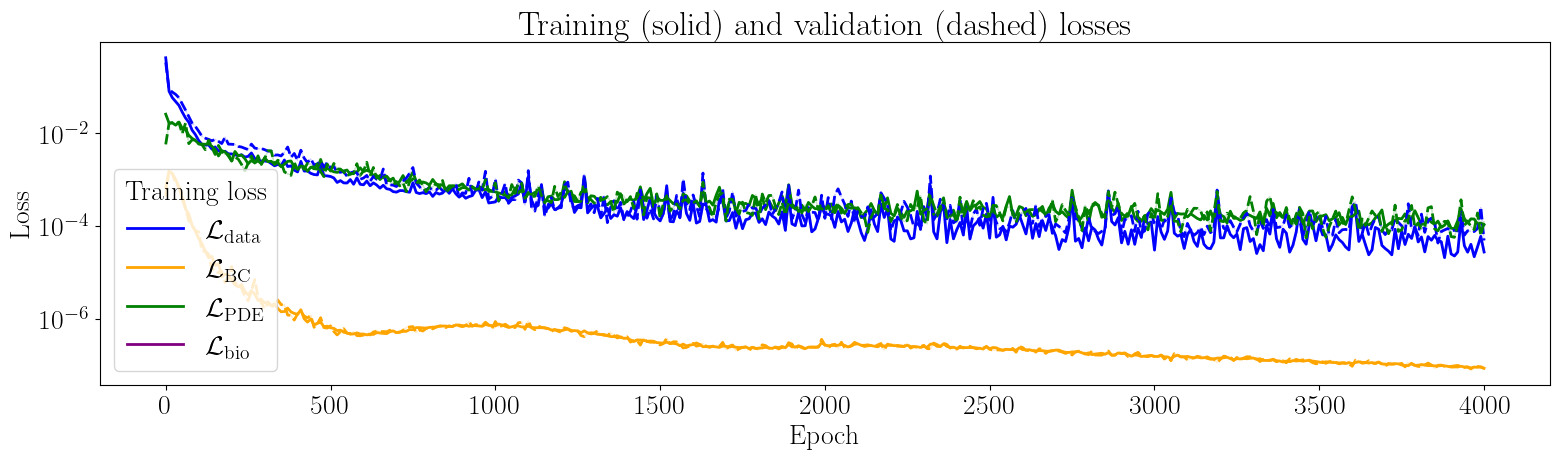

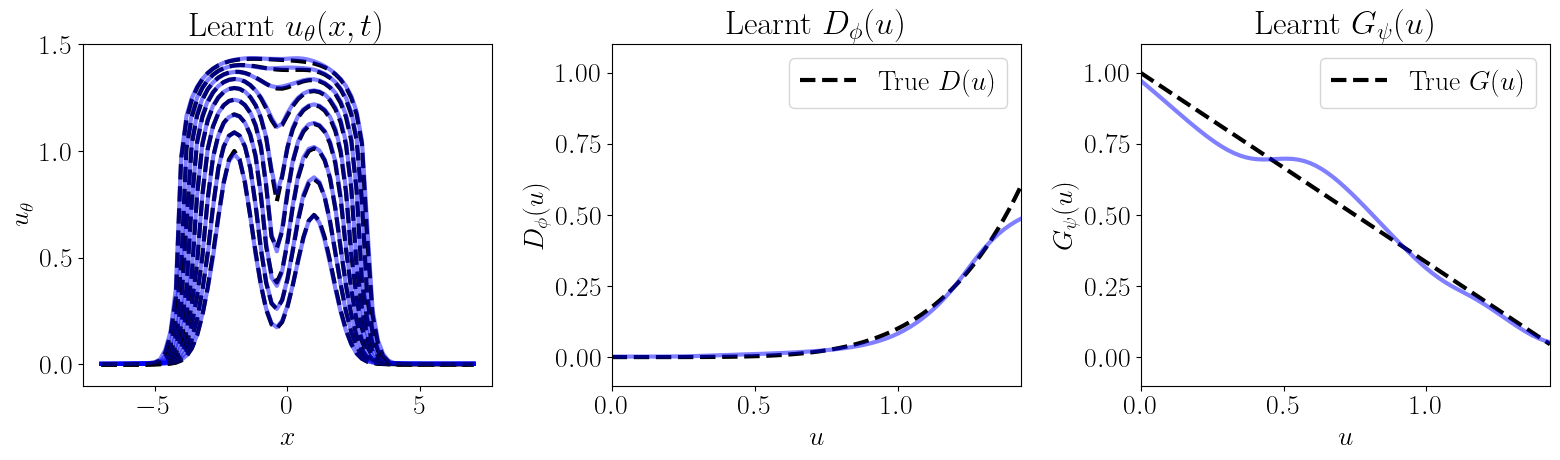

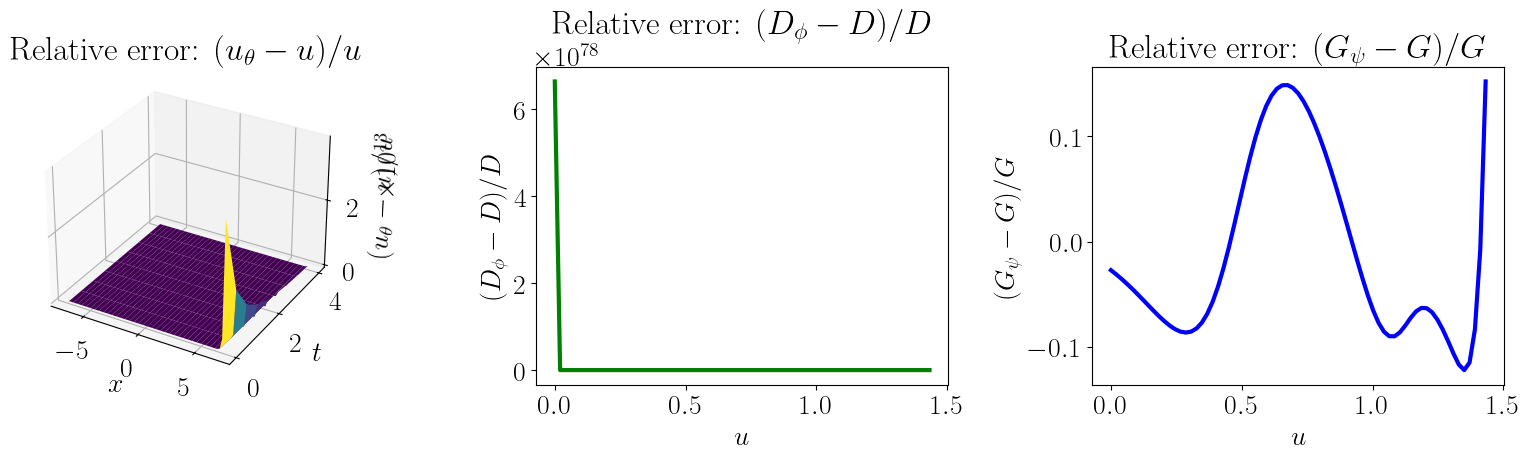

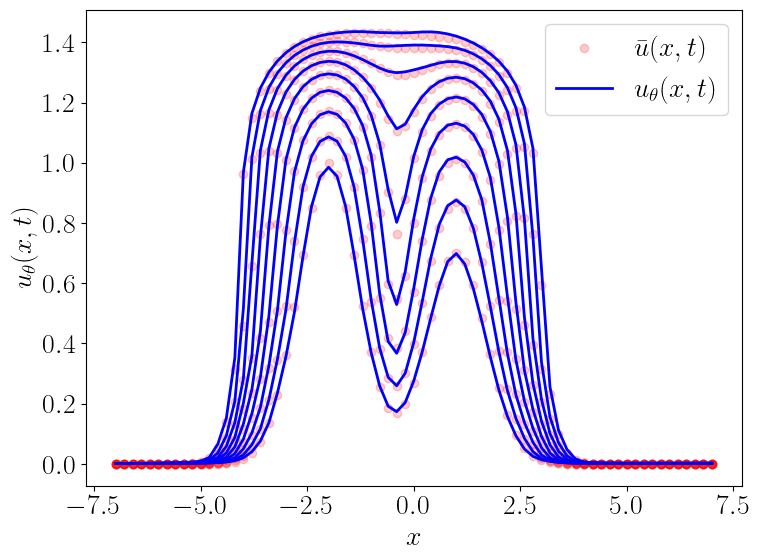

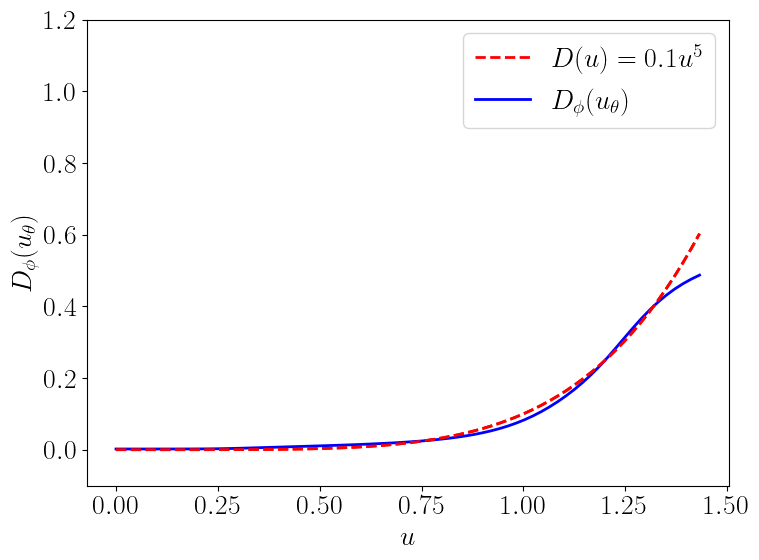

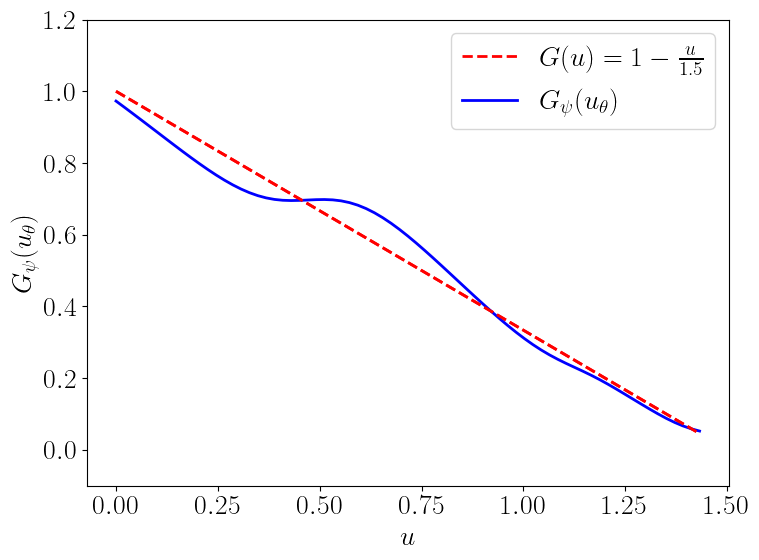

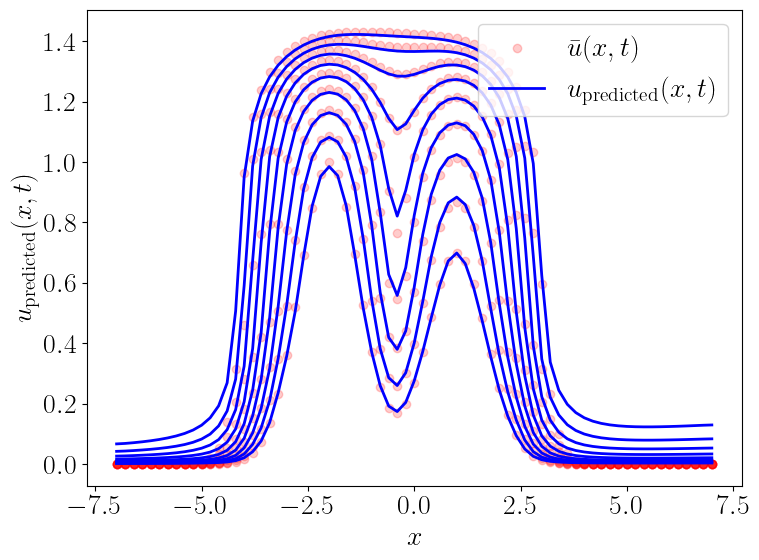

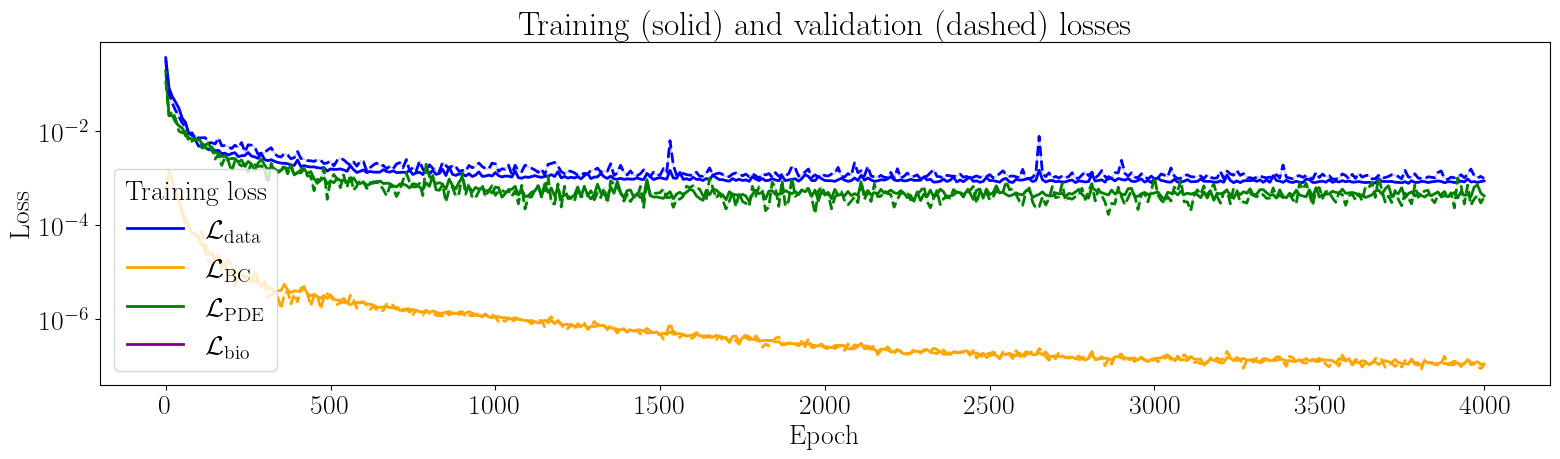

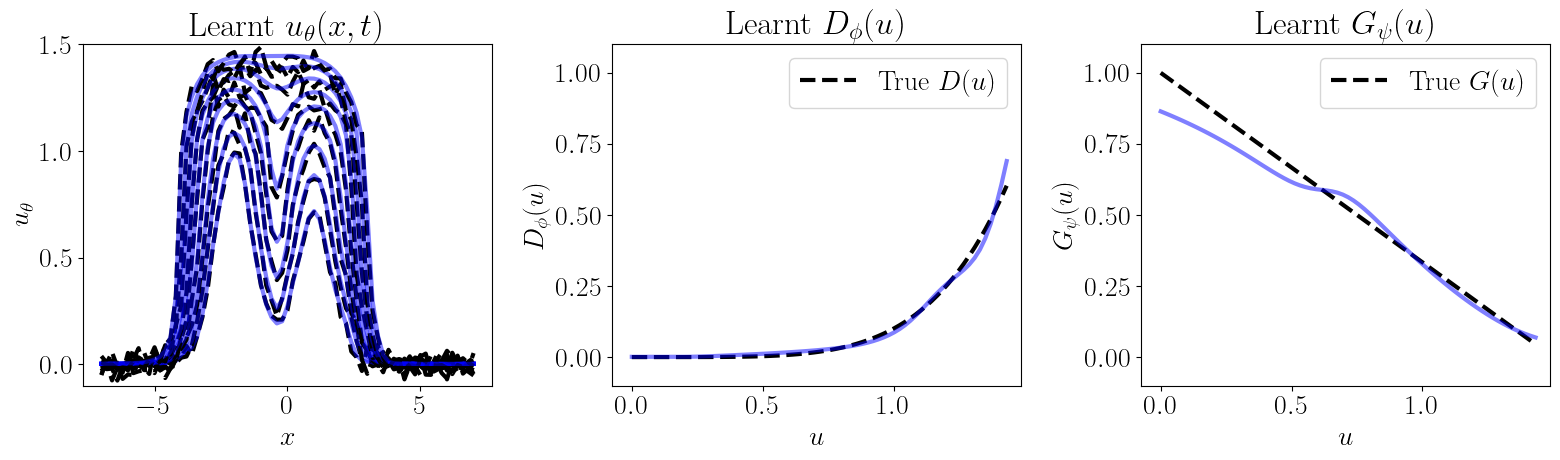

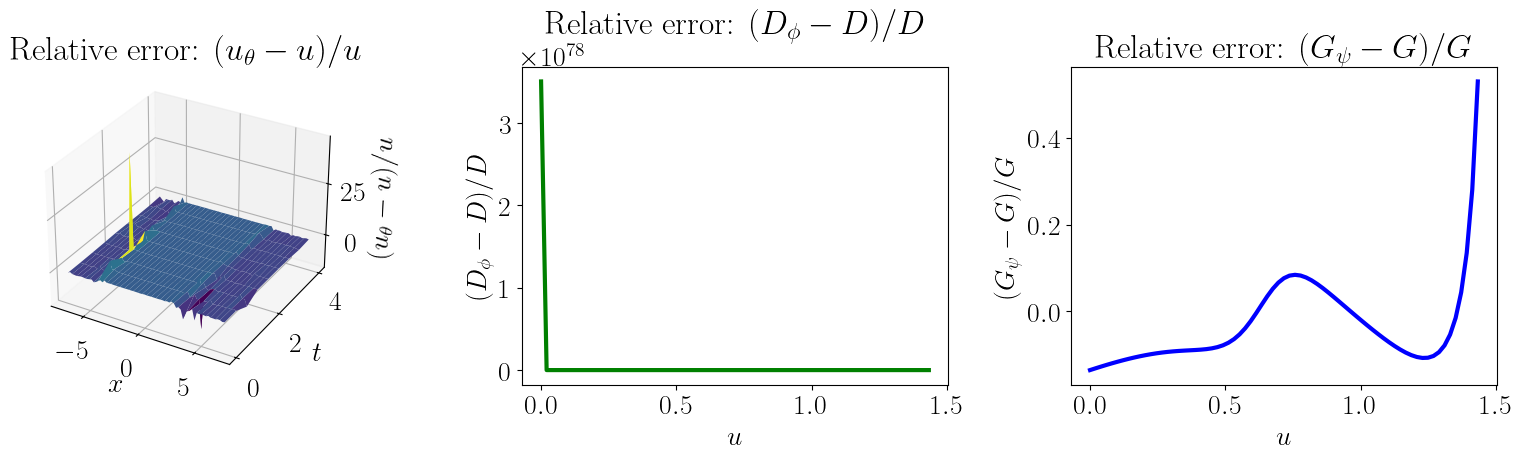

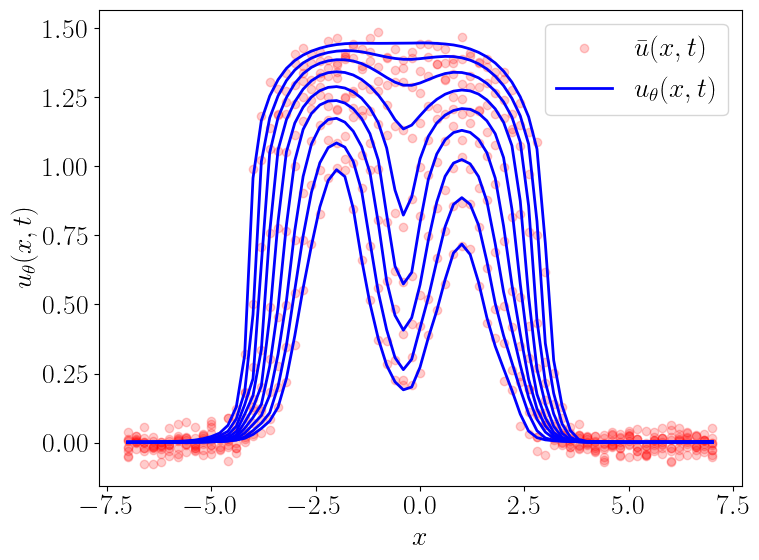

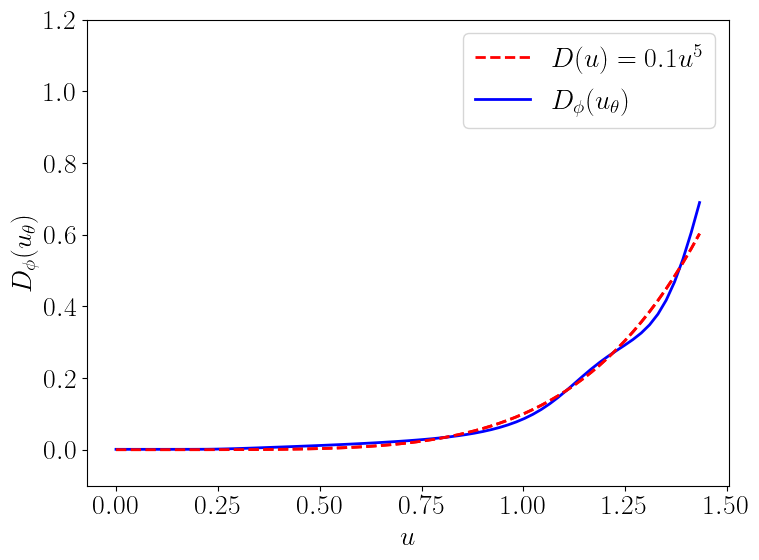

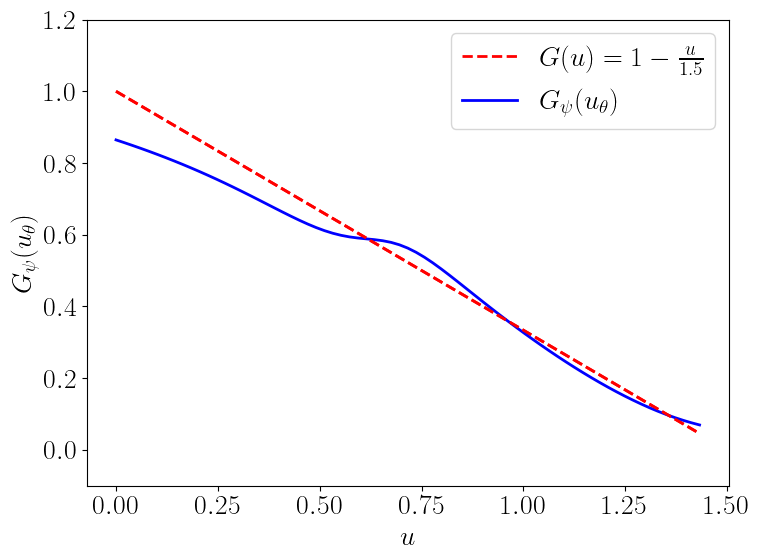

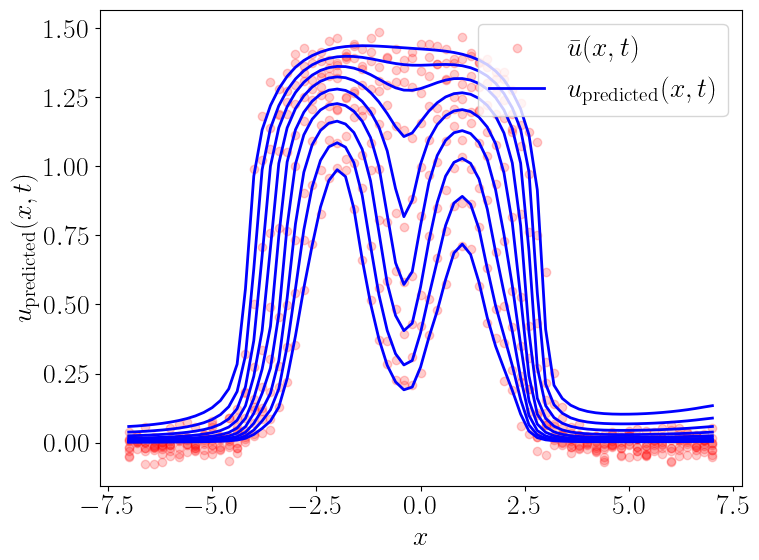

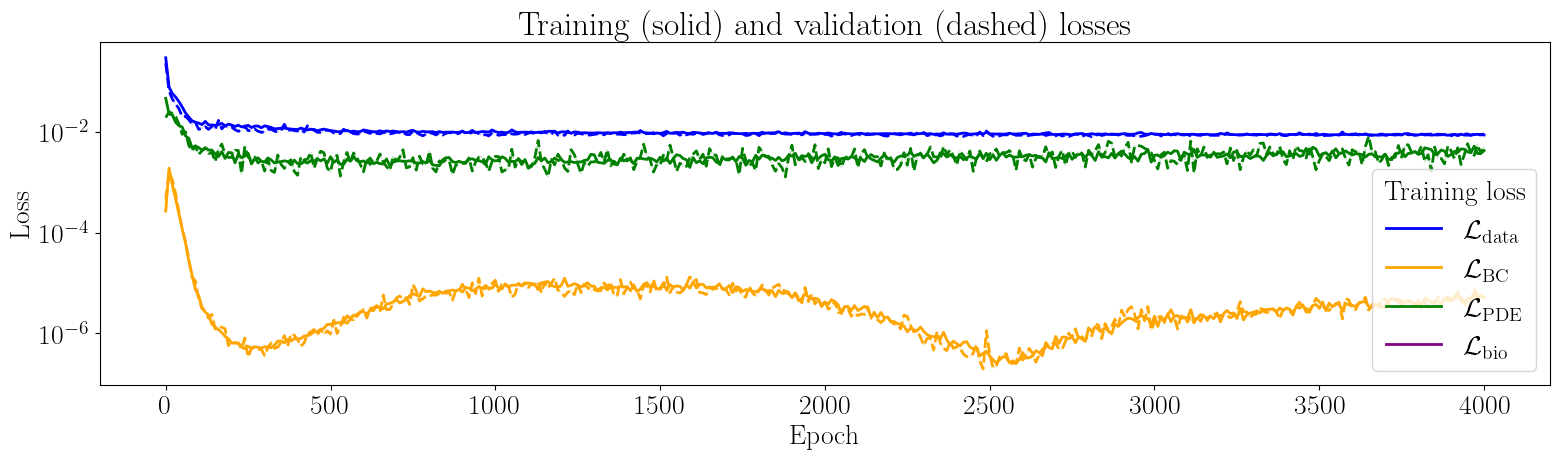

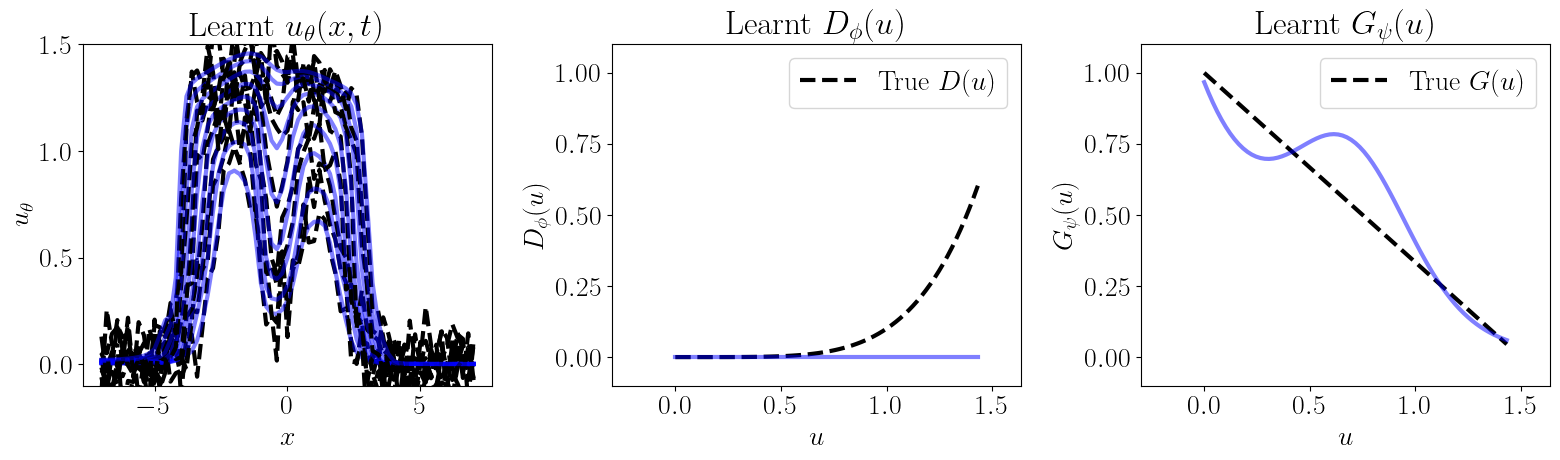

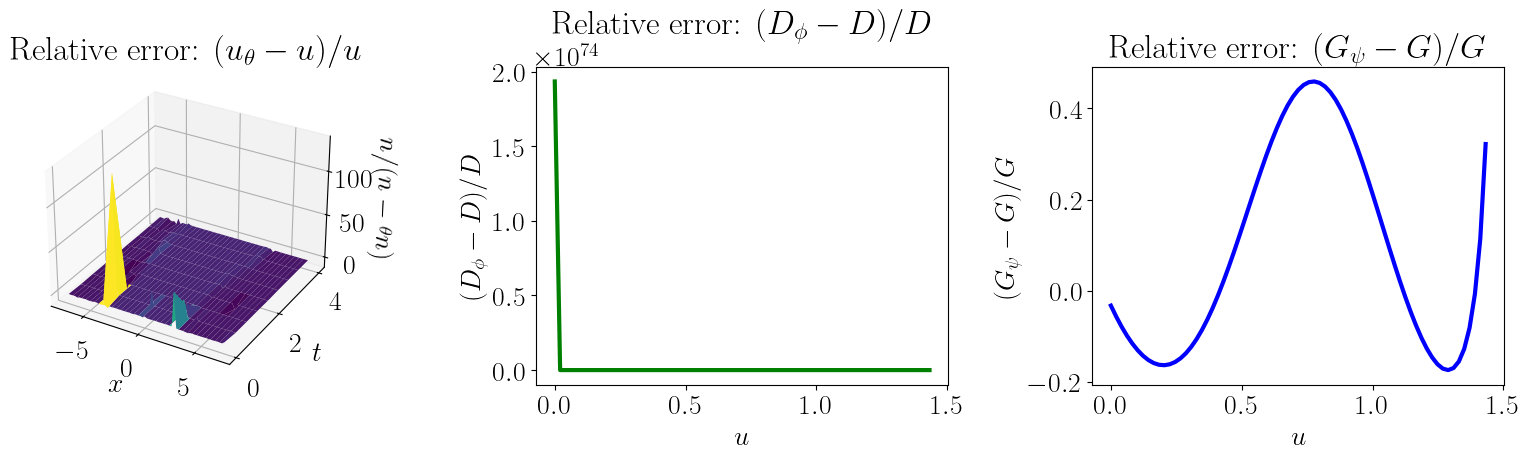

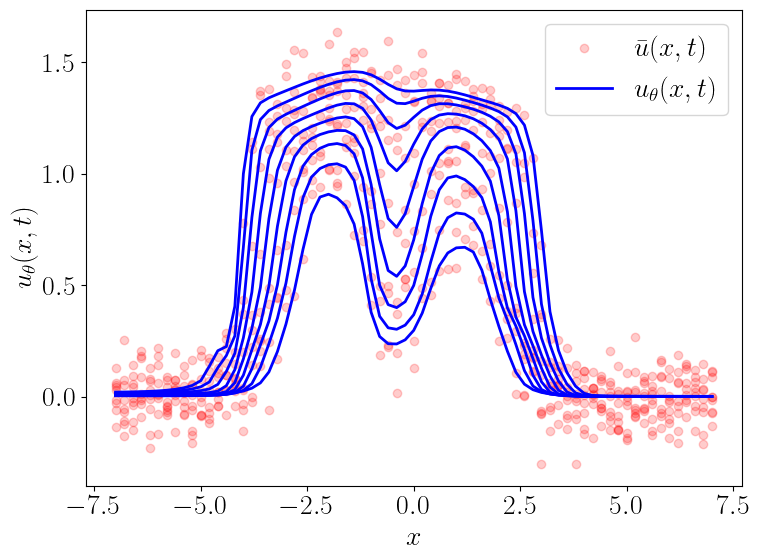

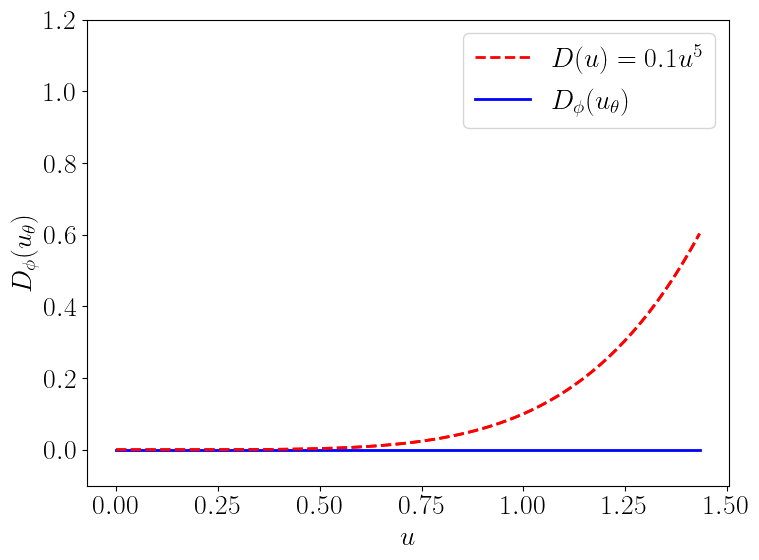

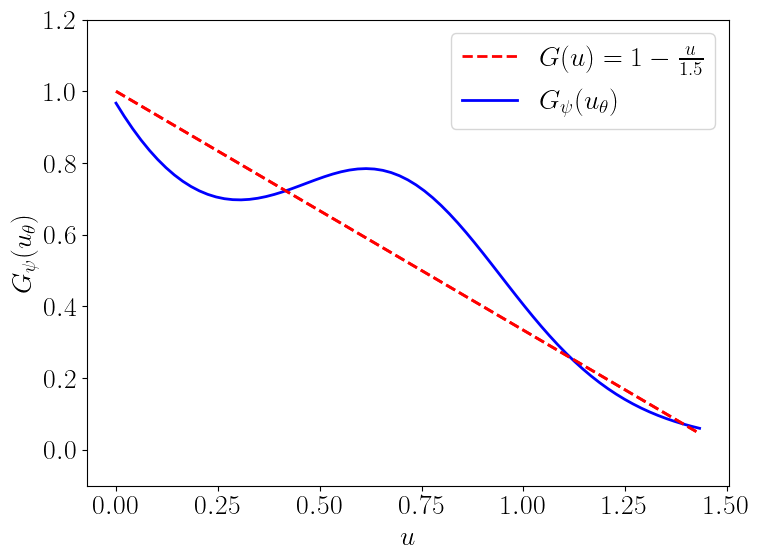

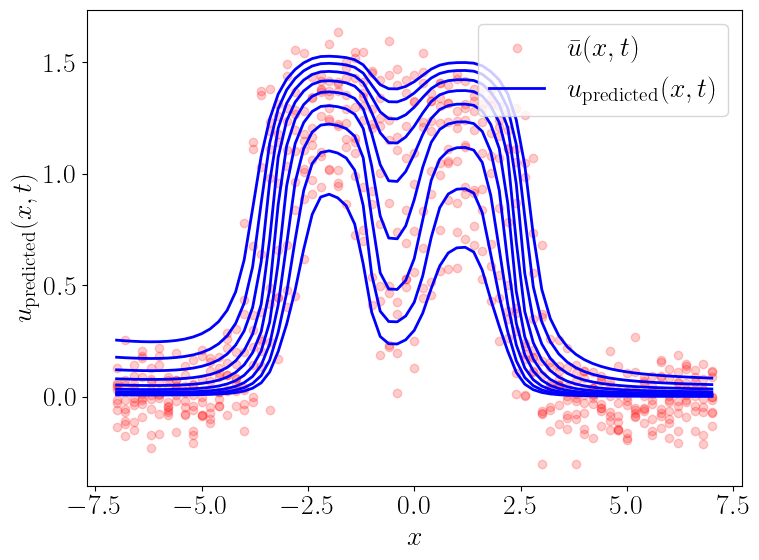

In [1]:
# import libraries and set the device
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import pandas as pd
import os
import sys
from torch.utils.data import TensorDataset
from scipy import integrate
from collections.abc import Callable
from typing import Tuple, Optional
from scipy.integrate import solve_ivp

from subfunction_ReactionDiffusion import *
%run subfunction_ReactionDiffusion.py

K_true = 1.5
D_base = 0.1

def G_func(u):
    # Standard logistic growth: u * (1 - u/K)
    return 1.0 - u / K_true
def D_func(u):
    # Your specific nonlinear D(u) function goes here
    # Example: D(u) = D_base * u**n or D_base * (1 + u)
    #return D_base * (3*(u**2))  # Example: D(u) = D_base * (3*u^2)
    return D_base * (u**5)  # Example: D(u) = D_base * (3*u^2)

def rhs(ti, y):
    u = y

    # 1. Extend u with ghost nodes to enforce Neumann BC: u_x = 0
    u_ext = np.empty(len(u) + 2)
    u_ext[1:-1] = u
    u_ext[0] = u[1]      # left ghost node (mirror)
    u_ext[-1] = u[-2]    # right ghost node (mirror)

    # 2. Compute first derivative using central differences
    ux = (u_ext[2:] - u_ext[:-2]) / (2 * dx)

    # 3. Compute flux: J = D(u) * du/dx
    flux = D_func(u) * ux

    # 4. Extend flux for divergence calculation
    flux_ext = np.empty(len(flux) + 2)
    flux_ext[1:-1] = flux
    flux_ext[0] = flux[1]
    flux_ext[-1] = flux[-2]

    # 5. Compute divergence of flux
    diffusion_term = (flux_ext[2:] - flux_ext[:-2]) / (2 * dx)

    # 6. Add reaction term
    return diffusion_term + u * G_func(u)


# Helper: wrap a PyTorch model that takes a torch tensor of shape (N,) or (N,1)
def make_torch_wrapper(pt_model, device="cpu", batch_dim=False):
    """
    Wrap a PyTorch model so it can be called as a numpy function u -> out (numpy array).
    - pt_model should accept a torch tensor of shape (N,) or (N,1) and return (N,) or (N,1)
    - device: 'cpu' or 'cuda'
    - batch_dim: if True, the model expects input shape (batch, N) or similar; keep False for elementwise
    Returns: callable(u_numpy) -> numpy array
    """
    pt_model.to(device)
    pt_model.eval()
    def wrapper(u_np: np.ndarray) -> np.ndarray:
        # Convert to torch tensor
        with torch.no_grad():
            u_t = torch.from_numpy(u_np.astype(np.float32)).to(device)
            # If model expects shape (N,1), reshape
            if u_t.ndim == 1:
                u_t_in = u_t.unsqueeze(1)  # (N,1)
            else:
                u_t_in = u_t
            out = pt_model(u_t_in)
            # If out has shape (N,1) or (N,), convert to 1D numpy
            out_np = out.detach().cpu().numpy()
            out_np = out_np.reshape(u_np.shape)
        return out_np
    return wrapper

def recon_plot(x_train, t_train, D_model, f_model, u_true_IC):
    D_callable = make_torch_wrapper(D_model, device='cpu')
    f_callable = make_torch_wrapper(f_model, device='cpu')
    u_sim = simulate_pde(x_train, u_true_IC, D_callable, f_callable,
                       t_span=(t_train[0], t_train[-1]),
                       t_eval=t_train,
                       integrator="RK45")
    return u_sim

def simulate_pde(x: np.ndarray,
                 IC: np.ndarray,
                 D_callable: Callable[[np.ndarray], np.ndarray],
                 f_callable: Callable[[np.ndarray], np.ndarray],
                 t_span: Tuple[float, float] = (0.0, 20.0),
                 t_eval: np.ndarray = None,
                 integrator: str = "RK45",
                 rtol: float = 1e-6,
                 atol: float = 1e-8,
                 save_path: str = None):
    """
    Simulate u_t = (D(u) u_x)_x + u * f(u)
    Inputs:
      x           : 1D grid (numpy array)
      IC          : initial condition (numpy array same length as x)
      D_callable  : function(u_array) -> D_array (same length as u)
      f_callable  : function(u_array) -> f_array (same length as u); PDE uses u * f(u)
      t_span      : (t0, tf)
      t_eval      : times to evaluate solution; default 201 points between t0 and tf
      integrator  : "RK45" or "BDF" etc; BDF recommended if stiff
      rtol, atol  : tolerances for solve_ivp
      save_path   : optional path to save final u as npy
    Returns:
      sol : the SciPy OdeResult-like object from solve_ivp (sol.y shape (N, len(t_eval)))
    """
    
    x = np.asarray(x)
    N = x.size
    dx = x[1] - x[0]
    assert IC.shape == x.shape, "IC must match x shape"
    if t_eval is None:
        t_eval = np.linspace(t_span[0], t_span[1], 201)

    def rhs(t, u_vec):
        u = np.asarray(u_vec)

        Dn = D_callable(u)
        if Dn.shape != u.shape:
            raise ValueError("D_callable must return array of same shape as u")

        u_ext = np.empty(N + 2, dtype=u.dtype)
        u_ext[1:-1] = u
        u_ext[0] = u[1]
        u_ext[-1] = u[-2]

        D_ext = np.empty(N + 2, dtype=Dn.dtype)
        D_ext[1:-1] = Dn
        D_ext[0] = Dn[1]
        D_ext[-1] = Dn[-2]

        D_half = 0.5 * (D_ext[:-1] + D_ext[1:])
        flux = D_half * (u_ext[1:] - u_ext[:-1]) / dx
        diffusion_term = (flux[1:] - flux[:-1]) / dx

        fu = f_callable(u)
        if fu.shape != u.shape:
            raise ValueError("f_callable must return array same shape as u")
        reaction_term = u * fu

        return diffusion_term + reaction_term
    
    sol = solve_ivp(rhs, t_span, IC, method=integrator, t_eval=t_eval, rtol=rtol, atol=atol)
    if not sol.success:
        print("Warning: solver reported failure:", sol.message)
    if save_path is not None:
        np.save(save_path, sol.y[:, -1])
        print(f"Saved final state to {save_path}")
    return sol.y.T


# plot formatting
plt.rcParams['font.family'] = 'overall_overall_times New Roman'
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.labelweight'] = 'bold'  # Bold axis labels
plt.rcParams['axes.titleweight'] = 'bold'  # Bold title
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['font.size'] = str(20)
plt.rcParams['lines.linewidth'] = 2
alpha_val = 0.4

if __name__ == "__main__":
    
    # set the device 
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') 

    K_true = 1.5
    D_base = 0.1

    # space resolution
    L = 7.0
    x_min, x_max = -L, L
    dx = 0.04
    x_train = np.arange(x_min, x_max+dx, dx)
    Nx = len(x_train)

    # time resolution
    Nt, t_end, t_min = 9, 4.0, 0.0
    t_train = np.linspace(t_min, t_end, Nt)
    
    # potential initial conditions (ICs) for training data generation
    def make_ic(kind, params):
        if kind == "step":
            c = params.get("center", 0.0)
            return (x_train < c).astype(float)
        if kind == "gauss":
            c = params.get("center", 0.0)
            s = params.get("sigma", 0.7)
            a = params.get("amp", 0.8)
            return a * np.exp(-0.5*((x_train-c)/s)**2)
        if kind == "bump":
            c1 = params.get("c1", -1.5)
            c2 = params.get("c2", 1.5)
            s  = params.get("sigma", 0.6)
            u0 = np.exp(-0.5*((x_train-c1)/s)**2) + 0.7*np.exp(-0.5*((x_train-c2)/s)**2)
            return np.minimum(u0, 1.0)
        raise ValueError("Unknown IC type")
    # choose one IC type and parameters for training data generation:
    kind, params = "bump", {"c1": -2.0, "c2": 1.0, "sigma": 0.7}
    u0_i = make_ic(kind, params)

    # numerically obtain the training data by solving the PDE using solve_ivp
    sol_i = integrate.solve_ivp(
    rhs, 
    (t_train[0], t_train[-1]), 
    u0_i, 
    t_eval=t_train, 
    method="RK45", 
    rtol=1e-6, 
    atol=1e-8
    )
    u_train_nonoise = sol_i.y.T # shape (Nt, Nx)
    X, T = np.meshgrid(x_train, sol_i.t)

    # ## YY: subsampling: 1/5th of the datapoints (in space) ----------------------------------
    x_train = x_train[::5]
    dx = x_train[1] - x_train[0]
    Nx = len(x_train)
    X, T = np.meshgrid(x_train, t_train)
    u_train_nonoise = u_train_nonoise[:, ::5]
    

    u_min_np, u_max_np = u_train_nonoise.min(), u_train_nonoise.max()
    shape = u_train_nonoise.shape
    # Resolutions of evaluating the learnt u_net and D_net after training
    # 1). evaluate U_net at 'grid_points_tensor'
    grid_points = np.vstack([X.flatten(), T.flatten()]).T
    grid_points_tensor = torch.tensor(grid_points, dtype=torch.float32).to(device)
    # 2). evaluate D_net at 'U_grid_tensor'
    U_grid = np.linspace(u_min_np, u_max_np, Nx) 
    U_grid_tensor = torch.tensor(U_grid, dtype=torch.float32).to(device)
    G_true = 1.0 - U_grid / K_true
    D_true = D_base * (U_grid**5)

    # prepare the dataset as tensors for training
    input_data = np.concatenate([X.reshape(-1)[:, None], T.reshape(-1)[:, None]], axis=1)
    

    # Add noise to the training data
    seed = 2 # for reproducibility
    np.random.seed(seed)

    batch_size, N_pde, N_bc, N_bio = 40, 40, 40, 40
    data_weight, pde_weight, bc_weight= 1.0, 1e-1, 1e-3
    bio_constraint_bool = True
    u_bio_weight, D_bio_weight, G_bio_weight = 1e-1, 1e-1, 1e-1
    init_learning_rate = 5e-4
    u_num_layers, u_hidden_units = 4, 32
    u_activation_fn = nn.Tanh()
    D_num_layers, D_hidden_units = 4, 32
    D_activation_fn = nn.Tanh()
    G_num_layers, G_hidden_units = 4, 32
    G_activation_fn = nn.Tanh()
    Numrep, Num_epochs, store_loss_step = 1, 4001, 10

    train_ratio, val_ratio = 0.8, 0.1 

    variances = [0.0, 0.001, 0.01]
    
    for variance in variances:
        
        #results_dir = f'Fig1_ReactionDiffusion_var{variance}/' 
        results_dir = f'Fig1_ReactionDiffusion_var{variance}_subsampled/' 
        save_dir = results_dir + 'ReactionDiffusion/' 
        os.makedirs(save_dir, exist_ok=True)

        noise_level = np.sqrt(variance)
        additive_noise = noise_level * np.random.randn(*shape)
        u_train_noise = u_train_nonoise + additive_noise
        u_true = u_train_noise.copy() # NOTE: no noise case
        output_data = u_train_noise.reshape(-1)[:, None]

    
        data = pd.DataFrame(np.hstack([input_data, output_data]), columns=['x', 't', 'u'])
        x_data = torch.tensor(data[['x', 't']].values, dtype=torch.float32).to(device)
        u_data = torch.tensor(data[['u']].values, dtype=torch.float32).to(device)
        # find the min and max of u for normalization
        u_min, u_max = u_data.min(), u_data.max()
        u_norm = u_max - u_min
        dataset = TensorDataset(x_data, u_data)
        # split the data into training, validation, and testing sets given different ratios
        train_size, val_size = int(len(dataset) * train_ratio), int(len(dataset) * val_ratio)
        test_size = len(dataset) - train_size - val_size
        train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, val_size, test_size])
        

        # save u_train_noise as a npy
        os.makedirs(results_dir, exist_ok=True)
        np.save(results_dir + f'u_train_var{variance}.npy', u_train_noise)
        #np.save(results_dir + f'u_train_var{variance}_subsampled.npy', u_train_noise)
        # ----------------------------------------------------------------------------------------------------

            
        TrainBINN(save_dir, device, D_true, t_end, batch_size, Numrep, Num_epochs, u_num_layers, u_hidden_units, u_activation_fn, \
            D_num_layers, D_hidden_units, D_activation_fn, init_learning_rate, data_weight, bc_weight, pde_weight, \
                N_pde, N_bc, store_loss_step, grid_points_tensor, U_grid, U_grid_tensor, t_train, x_train, u_true, X, T, Nt, u_min, u_max, \
                    N_bio, u_bio_weight, D_bio_weight, G_num_layers, G_hidden_units, G_activation_fn, G_true, bio_constraint_bool, \
                        val_dataset, test_dataset, train_dataset, x_max, x_min, t_min, G_bio_weight)


        # BINNs learned results paths
        u_file_path = results_dir + 'ReactionDiffusion/Iter0/fullgrid_u_pred.npy'
        D_file_path = results_dir + 'ReactionDiffusion/Iter0/fullgrid_D_pred.npy'
        G_file_path = results_dir + 'ReactionDiffusion/Iter0/fullgrid_G_pred.npy'
        u_learned, D_learned, G_learned = np.load(u_file_path), np.load(D_file_path), np.load(G_file_path)

        # predicted u from learnt 'D_net_best_Iter0.pth' and 'G_net_best_Iter0.pth'
        D_net_path = results_dir + 'ReactionDiffusion/Iter0/D_net_best_Iter0.pth'
        G_net_path = results_dir + 'ReactionDiffusion/Iter0/G_net_best_Iter0.pth'
        D_net = torch.load(D_net_path, map_location=device, weights_only=False)
        G_net = torch.load(G_net_path, map_location=device, weights_only=False)
        D_net.to(device)
        G_net.to(device)
        u_true_IC = u_learned[0, :]
        u_recon = recon_plot(x_train, t_train, D_net, G_net, u_true_IC)

        save_dir = results_dir + 'ReactionDiffusion/'
        dic = {
            'u_learned': u_learned,
            'D_learned': D_learned,
            'G_learned': G_learned,
            'u_true': u_true,
            'D_true': D_true,
            'G_true': G_true,
            'x_train': x_train,
            't_train': t_train,
            'U_grid': U_grid,
            'Nt': Nt,
            'u_recon': u_recon
        }
        np.save(save_dir + f'Fig1_ReactionDiffusion_data_var{variance}.npy', dic)

        # plot the results
        # plot u: 
        fig1, ax1 = plt.subplots(figsize=(8, 6))
        for t in range(Nt):
            # scatter for true u
            ax1.scatter(x_train, u_true[t, :], color='red', alpha=0.2, label=r'$\bar{u}(x, t)$' if t == 0 else "")
            ax1.plot(x_train, u_learned[t, :], 'blue', label=r'$u_{\theta}(x, t)$' if t == 0 else "")
        ax1.set_xlabel(r'$x$')
        ax1.set_ylabel(r'$u_{\theta}(x, t)$')
        ax1.legend(loc='upper right')
        fig1.tight_layout()
        fig1.savefig(save_dir + 'u_NN_OneSampleRun.svg', format='svg', bbox_inches='tight')

        # plot D(u):
        fig2, ax2 = plt.subplots(figsize=(8, 6))
        ax2.plot(U_grid, D_true, 'red', label=r'$D(u)=0.1u^5$', linestyle='--') # scatter for true D(u)
        ax2.plot(U_grid, D_learned, 'blue', label=r'$D_{\phi}(u_{\theta})$')
        ax2.plot(U_grid, D_true, 'red', linestyle='--')
        ax2.set_xlabel(r'$u$')
        ax2.set_ylabel(r'$D_{\phi}(u_{\theta})$')
        ax2.legend(loc='upper right')
        ax2.set_ylim([-0.1, 1.2])
        fig2.tight_layout()
        fig2.savefig(save_dir + 'D_NN_OneSampleRun.svg', format='svg', bbox_inches='tight')

        # plot G(u):
        fig3, ax3 = plt.subplots(figsize=(8, 6))
        ax3.plot(U_grid, G_true, 'red', label=r'$G(u)=1-\frac{u}{1.5}$', linestyle='--')
        ax3.plot(U_grid, G_learned, 'blue', label=r'$G_{\psi}(u_{\theta})$')
        ax3.plot(U_grid, G_true, 'red', linestyle='--')
        ax3.set_xlabel(r'$u$')
        ax3.set_ylabel(r'$G_{\psi}(u_{\theta})$')
        ax3.legend(loc='upper right')
        ax3.set_ylim([-0.1, 1.2])
        fig3.tight_layout()
        fig3.savefig(save_dir + 'G_NN_OneSampleRun.svg', format='svg', bbox_inches='tight')

        # plot u_predicted vs true u:
        fig5, ax5 = plt.subplots(figsize=(8, 6))
        for t in range(Nt):
            # scatter for true u
            ax5.scatter(x_train, u_true[t, :], color='red', alpha=0.2, label=r'$\bar{u}(x, t)$' if t == 0 else "")
            ax5.plot(x_train, u_recon[t, :], 'blue', label=r'$u_{\mathrm{predicted}}(x, t)$' if t == 0 else "")
        ax5.set_xlabel(r'$x$')
        ax5.set_ylabel(r'$u_{\mathrm{predicted}}(x, t)$')
        ax5.legend(loc='upper right')
        fig5.tight_layout()
        fig5.savefig(save_dir + 'u_reconstr_OneSampleRun.svg', format='svg', bbox_inches='tight')


